# 11 · Preparing the Gibbs state on a device: VarQITE

Every notebook so far quietly assumed we could *make* the state
$\rho(\theta) = e^{-G(\theta)}/Z$. The dense backend builds it by diagonalising
$G(\theta)$. Even the circuit backend's "exact" preparation diagonalises $G$ and then
synthesises the amplitudes into one big state-preparation unitary.

Neither is a quantum algorithm. Diagonalising a $2^n \times 2^n$ matrix is the thing we
wanted the quantum computer *for* — and Gibbs-state preparation is exactly the bottleneck
the whole QBM programme runs into on hardware.

This notebook closes that gap with **VarQITE** — variational quantum imaginary-time
evolution. It builds $\rho(\theta)$ from **expectation values only**, and it emits an
ordinary gate sequence you could send to a device.

## The gap, made concrete

Let's look at what the exact route actually produces.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import qbm
from qbm.circuits import varqite as vq
from qbm.circuits.adapters import to_qasm3

ham   = qbm.ParamHamiltonian(qbm.local_pauli_generators(2))
theta = np.random.default_rng(0).normal(scale=0.4, size=ham.n_params)

exact_prep = qbm.circuits.gibbs_preparation(ham, theta)
print("exact TFD preparation circuit:")
print("   ", exact_prep, "  gate counts:", exact_prep.gate_counts())
try:
    to_qasm3(exact_prep)
except ValueError as e:
    print("   export to OpenQASM 3 ->", type(e).__name__, ":", str(e)[:60], "...")

print("\nSo the 'circuit' is a single opaque 16x16 unitary, obtained from eigh(G).")
print("It validates our estimators perfectly -- and tells us nothing about hardware.")

exact TFD preparation circuit:
    Circuit('TFD', n_qubits=4, gates=1, depth=1)   gate counts: {'unitary': 1}
   export to OpenQASM 3 -> ValueError : cannot emit an opaque 'unitary' instruction as QASM; pass de ...

So the 'circuit' is a single opaque 16x16 unitary, obtained from eigh(G).
It validates our estimators perfectly -- and tells us nothing about hardware.


## The idea, in three lines

**1. Imaginary time makes Gibbs states.** Evolving under $e^{-\tau H}$ suppresses high
energies exactly the way a Boltzmann factor does. The normalised flow is

$$\frac{\partial}{\partial\tau}\,|\psi\rangle \;=\; -\bigl(H - \langle H\rangle\bigr)|\psi\rangle .$$

**2. It is not unitary, so we project it.** Restrict to a parameterised state
$|\psi(\lambda)\rangle$ and ask McLachlan's variational principle for the parameter
velocity that best tracks the flow — minimise
$\bigl\|\,(\partial_\tau + H - \langle H\rangle)\,|\psi(\lambda(\tau))\rangle\,\bigr\|$. The
minimiser solves a linear system,

$$A(\lambda)\,\dot\lambda = C(\lambda),\qquad
A_{ij} = \mathrm{Re}\bigl[\langle\partial_i\psi|\partial_j\psi\rangle-\langle\partial_i\psi|\psi\rangle\langle\psi|\partial_j\psi\rangle\bigr],\qquad
C_i = -\tfrac12\,\partial_i\langle H\rangle .$$

$A$ is the quantum geometric tensor and $C$ is minus half the energy gradient — so
**VarQITE is quantum natural gradient flow on the energy**, with the imaginary time step
playing the role of the learning rate. This library already has that geometry
(`qbm.optim.NaturalGradient`); here it reappears as *dynamics* rather than optimisation.

**3. Purify, and the mixed state comes for free.** Start from $n$ Bell pairs on $2n$
qubits — the infinite-temperature thermofield double, whose system marginal is
$I/2^n$. Because

$$|\mathrm{TFD}(\beta)\rangle \;\propto\; \bigl(e^{-\beta H/2}\otimes I\bigr)\,|\mathrm{TFD}(0)\rangle,$$

running imaginary time for $\tau = \beta/2$ transports the Bell pairs to
$|\mathrm{TFD}(\beta)\rangle$, and tracing out the ancillas leaves
$\rho = e^{-\beta H}/Z$.

## The one-liner

That is the whole algorithm. Here it is.

In [2]:
H = qbm.hamiltonians.tfim(2, J=1.0, g=0.8)          # transverse-field Ising, 2 qubits
res = vq.prepare_gibbs(H, beta=1.0, depth=3)

print(res.report())
print("\nprepared circuit:", res.circuit(), " gate counts:", res.circuit().gate_counts())
print("exports to OpenQASM 3:", to_qasm3(res.circuit()).splitlines()[0])

VarQITE Gibbs preparation
  ansatz       : 54 rotations on 4 qubits
  beta         : 1   (imaginary time tau = 0.5)
  steps        : 100
  energy       : -1.477414
  max residual : 1.790e-06   (0 = ansatz represents the flow exactly)
  infidelity   : 1.665e-06   (vs the exact TFD)
  trace dist.  : 6.199e-04   (vs the exact Gibbs state)

prepared circuit: Circuit('tfd-ansatz-d3', n_qubits=4, gates=280, depth=164)  gate counts: {'cx': 92, 'h': 68, 'rx': 66, 'rz': 54}
exports to OpenQASM 3: OPENQASM 3.0;


No eigendecomposition was used to *build* that state — only expectation values.
(`infidelity` and `trace dist.` are reported because we are in a simulator and can
cheat to check; on hardware you would have the `residual`, which we come back to.)

We passed a bare matrix, so `prepare_gibbs` had to guess: it built a *generic* 2-local
ansatz covering every one-body field and `XX`/`YY`/`ZZ` coupling. Give it a
`ParamHamiltonian` — or the Pauli `labels` of the terms — and it builds a
**Hamiltonian-adapted** ansatz instead, which is both much smaller and better. That is
what we use from here on. (When it has to guess and it is not sure, it says so with a
`RuntimeWarning`.)

## Why Bell pairs are the right starting point

At $\lambda = 0$ every rotation in the ansatz is the identity, so the circuit is exactly
the Bell-pair preparation. That is not an arbitrary initialisation — it *is* the
$\beta = 0$ thermal state.

In [3]:
ansatz = vq.tfd_ansatz(labels=["ZZ", "XI", "IX"], depth=3)
rho0 = qbm.purification.reduced_system_state(ansatz.state(np.zeros(ansatz.n_params)), 4)

print(ansatz)
print("\nsystem marginal at lambda = 0:")
print(np.round(rho0.real, 12))
print("\n= I/4, the infinite-temperature Gibbs state.  ||rho(0) - I/4|| =",
      f"{np.max(np.abs(rho0 - np.eye(4) / 4)):.1e}")

PauliRotationAnsatz('tfd-ansatz-d3', n_system=2, n_qubits=4, n_params=18)

system marginal at lambda = 0:
[[0.25 0.   0.   0.  ]
 [0.   0.25 0.   0.  ]
 [0.   0.   0.25 0.  ]
 [0.   0.   0.   0.25]]

= I/4, the infinite-temperature Gibbs state.  ||rho(0) - I/4|| = 0.0e+00


## The one construction that makes this work: the *tilt partner*

The ansatz rotations cannot be arbitrary. Imaginary-time evolution by a Hamiltonian term
$P$ has to be reproducible by *some* unitary rotation on the doubled register — and there
is a canonical one.

For an $n$-qubit Pauli string $P$, the **tilt partner** is the Hermitian Pauli
$K = A \otimes B$ on system $\otimes$ ancilla satisfying

$$K\,|\mathrm{TFD}(0)\rangle \;=\; -i\,(P \otimes I)\,|\mathrm{TFD}(0)\rangle,$$

so that $e^{-i\lambda K/2}$ moves the maximally entangled state precisely the way
$e^{-\tau P}$ does. It is constructed by taking $B = X_s$ on one ancilla site $s$ in the
support of $P$; then $A = -i\,P X_s$ is again a Hermitian Pauli.

The simplest case is the whole story in miniature: $Z \to Y \otimes X$.

In [4]:
for lbl in ["Z", "X", "Y", "ZZ", "XX", "ZIX"]:
    K = vq.tilt_partner(lbl)
    n = len(lbl)
    tfd0 = vq.PauliRotationAnsatz([K], n_system=n).initial_state()
    lhs = qbm.pauli(K) @ tfd0
    rhs = -1j * np.kron(qbm.pauli(lbl), np.eye(1 << n)) @ tfd0
    ok = np.allclose(lhs, rhs) or np.allclose(lhs, -rhs)
    print(f"   P = {lbl:5s} ->  K = {K:8s}   K|TFD(0)> = -i (P (x) I)|TFD(0)> : {ok}")

print("\nOne Y(x)X rotation on a Bell pair therefore sweeps out the ENTIRE")
print("single-qubit thermal family.  Nothing else is needed at n = 1.")

   P = Z     ->  K = YX         K|TFD(0)> = -i (P (x) I)|TFD(0)> : True
   P = X     ->  K = YZ         K|TFD(0)> = -i (P (x) I)|TFD(0)> : True
   P = Y     ->  K = ZX         K|TFD(0)> = -i (P (x) I)|TFD(0)> : True
   P = ZZ    ->  K = YZXI       K|TFD(0)> = -i (P (x) I)|TFD(0)> : True
   P = XX    ->  K = YXZI       K|TFD(0)> = -i (P (x) I)|TFD(0)> : True
   P = ZIX   ->  K = YIXXII     K|TFD(0)> = -i (P (x) I)|TFD(0)> : True

One Y(x)X rotation on a Bell pair therefore sweeps out the ENTIRE
single-qubit thermal family.  Nothing else is needed at n = 1.


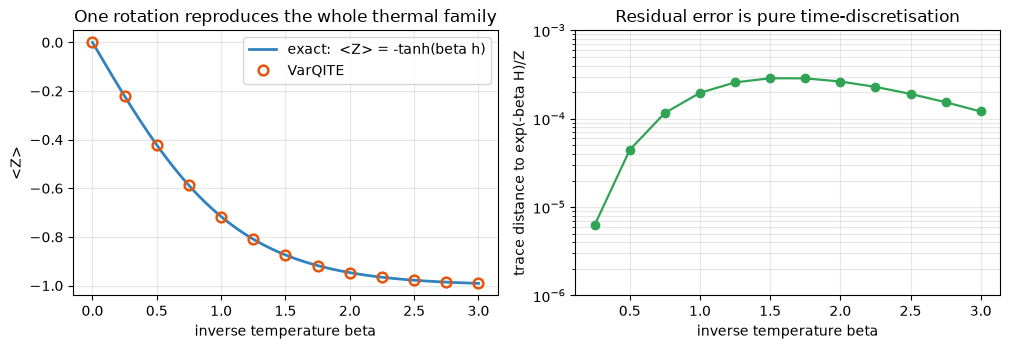

In [5]:
h = 0.9
betas = np.linspace(0.0, 3.0, 13)
z_var, td_var = [], []
for b in betas:
    r = vq.prepare_gibbs(h * qbm.pauli("Z"), beta=b, depth=1, steps=200)
    z_var.append(np.real(np.trace(r.density_matrix() @ qbm.pauli("Z"))))
    td_var.append(max(r.trace_distance(), 1e-16))

bb = np.linspace(0, 3, 300)
fig, ax = plt.subplots(1, 2, figsize=(10.2, 3.6))
ax[0].plot(bb, -np.tanh(h * bb), lw=2, c="#3182bd", label="exact:  <Z> = -tanh(beta h)")
ax[0].plot(betas, z_var, "o", ms=7, mfc="none", mew=1.8, c="#e6550d", label="VarQITE")
ax[0].set_xlabel("inverse temperature beta"); ax[0].set_ylabel("<Z>")
ax[0].set_title("One rotation reproduces the whole thermal family")
ax[0].legend(); ax[0].grid(alpha=0.3)

ax[1].semilogy(betas[1:], td_var[1:], "o-", c="#31a354", lw=1.6)   # beta=0 is exact
ax[1].set_xlabel("inverse temperature beta")
ax[1].set_ylabel("trace distance to exp(-beta H)/Z")
ax[1].set_title("Residual error is pure time-discretisation")
ax[1].set_ylim(1e-6, 1e-3)
ax[1].grid(alpha=0.3, which="both")
plt.tight_layout(); plt.show()

## Watching the flow

Now a genuinely non-commuting Hamiltonian, where the ansatz can only *approximate* the
imaginary-time trajectory. We record the state at every time step and compare it with
exact imaginary-time evolution.

Three things to watch:

* the energy $\langle H\rangle$ should descend along the exact thermal-energy curve;
* the infidelity against the exact TFD should stay small and fall as we add layers;
* the **McLachlan residual** — the fraction of the flow the ansatz cannot represent —
  should behave the same way. That last one is the only one available on hardware.

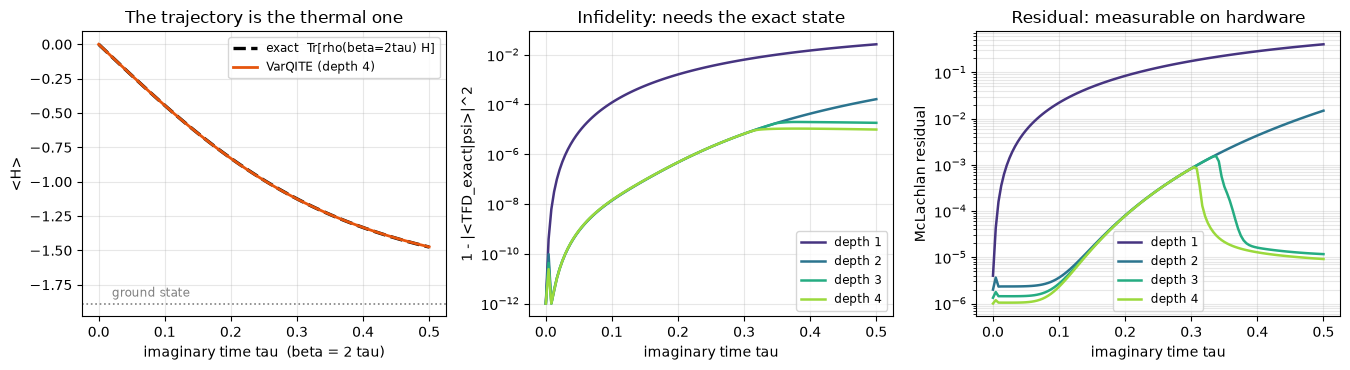

   depth 1:   6 rotations   max residual = 4.05e-01   infidelity = 2.63e-02   trace distance = 6.83e-02
   depth 2:  12 rotations   max residual = 1.48e-02   infidelity = 1.64e-04   trace distance = 9.40e-03
   depth 3:  18 rotations   max residual = 1.55e-03   infidelity = 1.83e-05   trace distance = 3.33e-03
   depth 4:  24 rotations   max residual = 8.89e-04   infidelity = 9.85e-06   trace distance = 2.36e-03


In [6]:
labels, coeffs = ["ZZ", "XI", "IX"], [-1.0, -0.8, -0.8]
H2 = sum(c * qbm.pauli(l) for c, l in zip(coeffs, labels))
depths = [1, 2, 3, 4]
runs = {
    d: vq.varqite(H2, vq.tfd_ansatz(labels=labels, depth=d), tau=0.5, steps=120,
                  track_exact=True)
    for d in depths
}

# exact thermal energy along the same imaginary-time axis
taus = runs[4].history["tau"]
E_exact = [np.real(np.trace(vq.exact_gibbs(H2, 2 * t) @ H2)) for t in taus]
E_ground = np.linalg.eigvalsh(H2)[0]

colors = plt.cm.viridis(np.linspace(0.15, 0.85, len(depths)))
fig, ax = plt.subplots(1, 3, figsize=(13.6, 3.8))

ax[0].plot(taus, E_exact, "k--", lw=2.4, label="exact  Tr[rho(beta=2tau) H]")
ax[0].plot(taus, runs[4].history["energy"], lw=2, c="#e6550d", label="VarQITE (depth 4)")
ax[0].axhline(E_ground, color="grey", ls=":", lw=1.2)
ax[0].text(0.02, E_ground + 0.05, "ground state", color="grey", fontsize=8.5)
ax[0].set_xlabel("imaginary time tau  (beta = 2 tau)"); ax[0].set_ylabel("<H>")
ax[0].set_title("The trajectory is the thermal one")
ax[0].legend(fontsize=8.5); ax[0].grid(alpha=0.3)

for c, d in zip(colors, depths):
    ax[1].semilogy(taus, np.maximum(runs[d].history["infidelity"], 1e-12),
                   lw=1.8, c=c, label=f"depth {d}")
ax[1].set_xlabel("imaginary time tau"); ax[1].set_ylabel("1 - |<TFD_exact|psi>|^2")
ax[1].set_title("Infidelity: needs the exact state")
ax[1].legend(fontsize=8.5); ax[1].grid(alpha=0.3, which="both")

for c, d in zip(colors, depths):
    ax[2].semilogy(taus, np.maximum(runs[d].history["residual"], 1e-12),
                   lw=1.8, c=c, label=f"depth {d}")
ax[2].set_xlabel("imaginary time tau"); ax[2].set_ylabel("McLachlan residual")
ax[2].set_title("Residual: measurable on hardware")
ax[2].legend(fontsize=8.5); ax[2].grid(alpha=0.3, which="both")
plt.tight_layout(); plt.show()

for d in depths:
    r = runs[d]
    print(f"   depth {d}:  {r.ansatz.n_params:2d} rotations   "
          f"max residual = {r.residual:.2e}   infidelity = {r.infidelity():.2e}   "
          f"trace distance = {r.trace_distance():.2e}")

## The residual is the error bar you can actually measure

The middle and right panels above have the same shape, and that is the point.

At the McLachlan solution the residual has a closed form,

$$\bigl\|(\partial_\tau + H - \langle H\rangle)|\psi\rangle\bigr\|^2
  \;=\; \mathrm{Var}(H) - C\cdot\dot\lambda ,$$

which we normalise by $\mathrm{Var}(H)$ — the norm of the flow itself — to get a number
in $[0, 1]$. Zero means the ansatz reproduces imaginary-time evolution *exactly*; one
means it cannot move at all.

Every ingredient is an expectation value, so unlike fidelity or trace distance this
survives on hardware.

One caveat worth being precise about: the residual measures only what the **ansatz**
cannot represent. The other error source — the first-order Euler discretisation of the
ODE — is invisible to it, and sets a floor below which a smaller residual buys you
nothing. Both are visible in the scatter below.

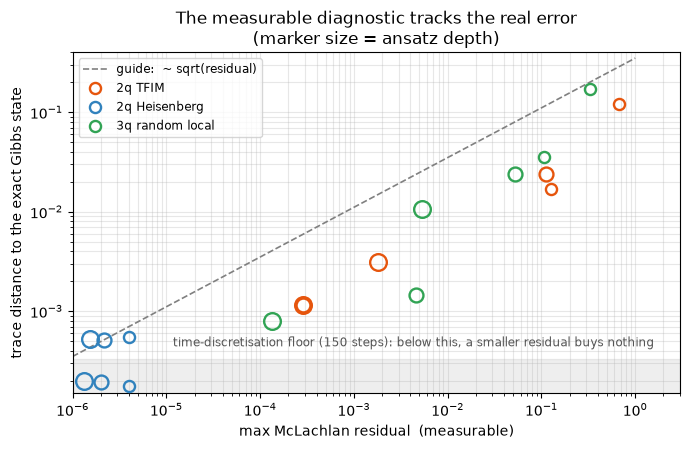

In [7]:
STEPS = 150
H3r_labels = qbm.local_pauli_generators(3)
rng = np.random.default_rng(0)
H3r = sum(c * qbm.pauli(l) for c, l in
          zip(rng.normal(scale=0.5, size=len(H3r_labels)), H3r_labels))
problems = [
    ("2q TFIM",        labels,           H2,                                     "#e6550d"),
    ("2q Heisenberg",  ["XX","YY","ZZ"], qbm.hamiltonians.heisenberg(2, J=0.6),  "#3182bd"),
    ("3q random local", H3r_labels,      H3r,                                    "#31a354"),
]
cases = []
for name, lbls, Hc, col in problems:
    for d in (1, 2, 3):
        for beta in (0.5, 1.5):
            r = vq.varqite(Hc, vq.tfd_ansatz(labels=lbls, depth=d), tau=beta / 2, steps=STEPS)
            cases.append((name, col, d, r.residual, r.trace_distance()))

# the discretisation floor: a Hamiltonian whose flow the ansatz represents EXACTLY,
# so whatever error remains is the ODE solver's
ising_labels, ising_coeffs = ["ZI", "IZ", "ZZ"], [0.7, -0.4, 0.9]
H_cl = sum(c * qbm.pauli(l) for c, l in zip(ising_coeffs, ising_labels))
floor = vq.varqite(H_cl, vq.tfd_ansatz(labels=ising_labels, depth=1),
                   tau=0.5, steps=STEPS).trace_distance()

fig, ax = plt.subplots(figsize=(7.0, 4.6))
ax.axhspan(1e-9, floor, color="grey", alpha=0.13, zorder=0)
g = np.logspace(-6, 0, 50)
ax.loglog(g, np.sqrt(g) * 0.35, "--", c="grey", lw=1.2, label="guide:  ~ sqrt(residual)")
seen = set()
for name, col, d, resid, td in cases:
    ax.loglog(max(resid, 1e-9), max(td, 1e-9), "o", ms=6 + 2 * d, mfc="none", mew=1.7,
              c=col, label=name if name not in seen else None, zorder=3)
    seen.add(name)
ax.set_xlim(1e-6, 3); ax.set_ylim(1.5e-4, 4e-1)
ax.text(1.6, floor * 1.25, f"time-discretisation floor ({STEPS} steps): "
        "below this, a smaller residual buys nothing",
        fontsize=8.5, color="#555", ha="right", va="bottom")
ax.set_xlabel("max McLachlan residual  (measurable)")
ax.set_ylabel("trace distance to the exact Gibbs state")
ax.set_title("The measurable diagnostic tracks the real error\n(marker size = ansatz depth)")
ax.legend(fontsize=8.5, loc="upper left"); ax.grid(alpha=0.3, which="both")
plt.tight_layout(); plt.show()

## What failure looks like

Ansatz design is where this algorithm goes wrong, and it can go wrong *silently* if you
only look at the energy. Here is a perfectly reasonable-looking ansatz — one rotation per
Hamiltonian term, acting on the system register — that cannot prepare anything at all.

The reason: a unitary $V \otimes I$ on the system maps $I/2^n \mapsto V (I/2^n) V^\dagger
= I/2^n$. The state never leaves infinite temperature, so the energy gradient is
identically zero. Without tilt partners there is no thermal direction to move in.

In [8]:
stuck = vq.PauliRotationAnsatz([l + "II" for l in labels], n_system=2)
good  = vq.tfd_ansatz(labels=labels, depth=3)

print(f"   {'ansatz':24s} {'rotations':>9s} {'residual':>10s} "
      f"{'trace dist.':>12s} {'|rho - I/4|':>12s}")
print("   " + "-" * 71)
for name, a in [("system rotations only", stuck), ("with tilt partners", good)]:
    r = vq.varqite(H2, a, tau=0.5, steps=100)
    mixed = np.max(np.abs(r.density_matrix() - np.eye(4) / 4))
    print(f"   {name:24s} {a.n_params:9d} {r.residual:10.3f} "
          f"{r.trace_distance():12.4f} {mixed:12.1e}")

print("\nresidual = 1.000 means: the ansatz cannot represent ANY of the flow.")
print("You can see that from measurements alone, before trusting a single result.")

   ansatz                   rotations   residual  trace dist.  |rho - I/4|
   -----------------------------------------------------------------------
   system rotations only            3      1.000       0.4472      0.0e+00
   with tilt partners              18      0.002       0.0037      1.5e-01

residual = 1.000 means: the ansatz cannot represent ANY of the flow.
You can see that from measurements alone, before trusting a single result.


## It converges

Two knobs control the error, and they are independent:

* **ansatz depth** — how much of the imaginary-time flow is representable at all
  (the residual);
* **number of time steps** — the Euler discretisation of the ODE, first order in
  $\Delta\tau$.

For a *commuting* Hamiltonian the tilt-partner ansatz is exact at depth 1, so only the
second error survives and refining the step size drives everything to zero.

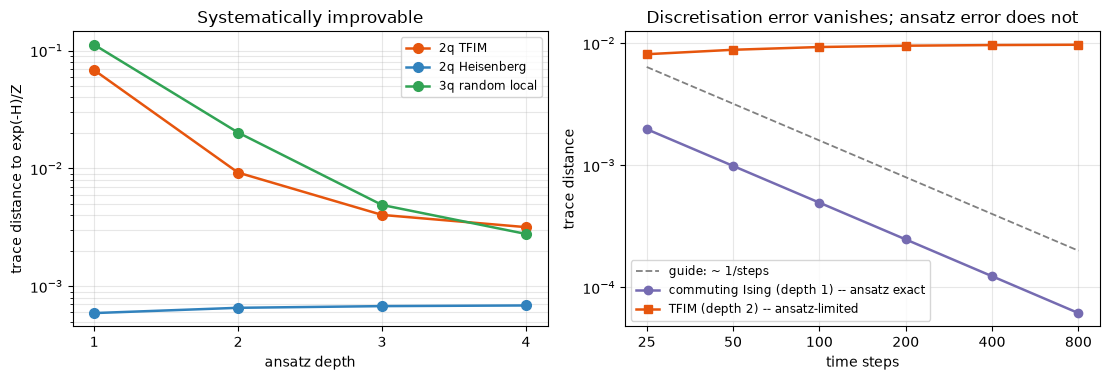

commuting Hamiltonian, depth 1: residual = 4.0e-06 -> the ansatz is exact, only the ODE solver limits accuracy


In [9]:
# (a) depth sweep on three problems;  (b) step-size convergence, commuting vs not
fig, ax = plt.subplots(1, 2, figsize=(11.2, 3.9))

for name, lbls, Hc, col in problems:
    ds = [1, 2, 3, 4]
    td = [vq.varqite(Hc, vq.tfd_ansatz(labels=lbls, depth=d), tau=0.5, steps=80).trace_distance()
          for d in ds]
    ax[0].semilogy(ds, td, "o-", c=col, lw=1.8, ms=7, label=name)
ax[0].set_xlabel("ansatz depth"); ax[0].set_ylabel("trace distance to exp(-H)/Z")
ax[0].set_xticks([1, 2, 3, 4])
ax[0].set_title("Systematically improvable")
ax[0].legend(fontsize=8.5); ax[0].grid(alpha=0.3, which="both")

steps_grid = np.array([25, 50, 100, 200, 400, 800])
cl = [vq.varqite(H_cl, vq.tfd_ansatz(labels=ising_labels, depth=1), tau=0.5, steps=s)
      for s in steps_grid]
nc = [vq.varqite(H2, vq.tfd_ansatz(labels=labels, depth=2), tau=0.5, steps=s)
      for s in steps_grid]
ax[1].loglog(steps_grid, 0.16 / steps_grid, "--", c="grey", lw=1.3, label="guide: ~ 1/steps")
ax[1].loglog(steps_grid, [r.trace_distance() for r in cl], "o-", c="#756bb1", lw=1.8,
             label="commuting Ising (depth 1) -- ansatz exact")
ax[1].loglog(steps_grid, [r.trace_distance() for r in nc], "s-", c="#e6550d", lw=1.8,
             label="TFIM (depth 2) -- ansatz-limited")
ax[1].set_xlabel("time steps"); ax[1].set_ylabel("trace distance")
ax[1].set_xticks(steps_grid); ax[1].set_xticklabels(steps_grid)
ax[1].minorticks_off()
ax[1].set_title("Discretisation error vanishes; ansatz error does not")
ax[1].legend(fontsize=8.5); ax[1].grid(alpha=0.3, which="both")
plt.tight_layout(); plt.show()

print(f"commuting Hamiltonian, depth 1: residual = {cl[0].residual:.1e} "
      "-> the ansatz is exact, only the ODE solver limits accuracy")

## Is this actually measurable?

Everything above ran on statevectors. That is fine for *studying* the algorithm, but the
claim is that VarQITE is a hardware procedure — so the library also implements
$A$ and $C$ the way a device gets them: **Hadamard tests with controlled-Pauli
insertions**.

Since every rotation is $U_k = e^{-i\lambda_k P_k/2}$, its derivative is
$\partial_k|\psi\rangle = U_L\cdots U_{k+1}\,(-\tfrac{i}{2}P_k)\,U_k\cdots U_1|\psi_0\rangle$
— the same circuit with one controlled Pauli inserted. Putting the ancilla in $|+\rangle$
and inserting $P_i$ on the $|0\rangle$ branch and $P_j$ on the $|1\rangle$ branch makes
$\langle Z\rangle$ on the ancilla return exactly $4A_{ij}$.

No matrices, no eigendecomposition — and it must agree with the exact route to machine
precision.

In [10]:
small = vq.tfd_ansatz(labels=labels, depth=1)
lam   = np.random.default_rng(5).normal(scale=0.5, size=small.n_params)

exact_sys = vq.mclachlan_system(small, lam, H2)
A_meas, C_meas = vq.measured_mclachlan_system(small, lam, labels, coeffs)

print(f"ansatz: {small.n_params} rotations")
print(f"   max |A_hadamard - A_exact| = {np.max(np.abs(A_meas - exact_sys['A'])):.2e}")
print(f"   max |C_hadamard - C_exact| = {np.max(np.abs(C_meas - exact_sys['C'])):.2e}")

circ = vq.mclachlan_circuit(small, lam, 0, j=3)
print(f"\none estimator circuit: {circ}")
print(f"   gate counts: {circ.gate_counts()}")
print(f"   exports to OpenQASM 3: {to_qasm3(circ).splitlines()[0]}  "
      f"({len(to_qasm3(circ).splitlines())} lines)")
print("\nThe whole VarQITE path is gate-level -- no opaque unitaries anywhere.")

ansatz: 6 rotations
   max |A_hadamard - A_exact| = 4.76e-16
   max |C_hadamard - C_exact| = 2.94e-15

one estimator circuit: Circuit('varqite-mclachlan', n_qubits=5, gates=42, depth=25)
   gate counts: {'cx': 15, 'cz': 1, 'h': 10, 'rx': 6, 'rz': 6, 's': 1, 'sdg': 1, 'x': 2}
   exports to OpenQASM 3: OPENQASM 3.0;  (47 lines)

The whole VarQITE path is gate-level -- no opaque unitaries anywhere.


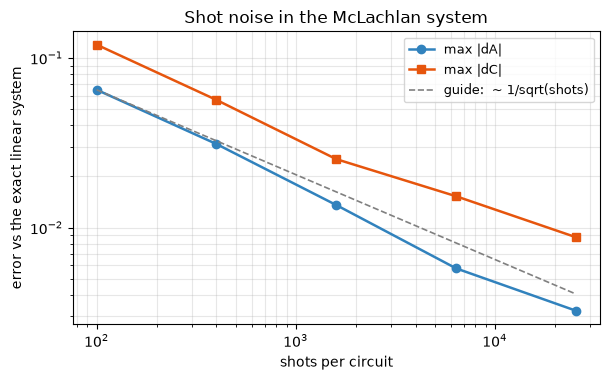

In [11]:
# how the measured system degrades with a finite shot budget
shot_grid = [100, 400, 1600, 6400, 25600]
rng = np.random.default_rng(0)
errA, errC = [], []
for s in shot_grid:
    ea, ec = [], []
    for _ in range(4):
        Am, Cm = vq.measured_mclachlan_system(small, lam, labels, coeffs, shots=s, rng=rng)
        ea.append(np.max(np.abs(Am - exact_sys["A"])))
        ec.append(np.max(np.abs(Cm - exact_sys["C"])))
    errA.append(np.mean(ea)); errC.append(np.mean(ec))

fig, ax = plt.subplots(figsize=(6.2, 3.9))
ax.loglog(shot_grid, errA, "o-", lw=1.8, c="#3182bd", label="max |dA|")
ax.loglog(shot_grid, errC, "s-", lw=1.8, c="#e6550d", label="max |dC|")
ax.loglog(shot_grid, errA[0] * np.sqrt(shot_grid[0] / np.array(shot_grid)), "--",
          c="grey", lw=1.2, label="guide:  ~ 1/sqrt(shots)")
ax.set_xlabel("shots per circuit"); ax.set_ylabel("error vs the exact linear system")
ax.set_title("Shot noise in the McLachlan system")
ax.legend(fontsize=9); ax.grid(alpha=0.3, which="both")
plt.tight_layout(); plt.show()

## Plugging it into the rest of the library

VarQITE is a *preparation strategy*, so it sits behind the same backend seam as
everything else. One argument swaps it in, and every downstream quantity — expectations,
the energy gradient, the α-z information matrices from notebook 9 — keeps working, now
computed on a variationally prepared state.

In [12]:
from qbm.backends.circuit import CircuitBackend
from qbm.metrics import AlphaZ

dense = qbm.DenseBackend().thermal_state(ham, theta)
O     = qbm.hamiltonians.tfim(2, g=1.2)
g_ref = dense.observable_gradient(O)
m_ref = dense.metric("wigner_yanase")

print(f"{'preparation':22s} {'max |d rho|':>12s} {'<O> error':>11s} "
      f"{'grad rel.err':>13s} {'metric rel.err':>15s}")
print("-" * 77)
for tag, kw in [
    ("exact TFD synthesis", dict(gibbs_prep="exact")),
    ("VarQITE depth 2",     dict(gibbs_prep="varqite", varqite_options={"depth": 2})),
    ("VarQITE depth 4",     dict(gibbs_prep="varqite", varqite_options={"depth": 4})),
]:
    st = CircuitBackend(seed=0, **kw).thermal_state(ham, theta)
    drho = np.max(np.abs(st.density_matrix() - dense.density_matrix()))
    ge = np.max(np.abs(st.observable_gradient(O) - g_ref)) / np.max(np.abs(g_ref))
    me = np.max(np.abs(st.metric(AlphaZ(0.5, 1.0)) - m_ref)) / np.max(np.abs(m_ref))
    print(f"{tag:22s} {drho:12.2e} {abs(st.expect(O) - dense.expect(O)):11.2e} "
          f"{ge:13.3f} {me:15.3f}")

print("\nThe first two columns are the preparation error, and they shrink with depth.")
print("The last two are dominated by Monte-Carlo sampling of the smearing time from")
print("notebook 9 -- the same for every preparation, which is why they do not move.")

preparation             max |d rho|   <O> error  grad rel.err  metric rel.err
-----------------------------------------------------------------------------
exact TFD synthesis        5.55e-17    1.39e-16         0.011           0.003
VarQITE depth 2            1.13e-04    1.27e-05         0.011           0.003


VarQITE depth 4            5.76e-05    5.83e-06         0.011           0.003

The first two columns are the preparation error, and they shrink with depth.
The last two are dominated by Monte-Carlo sampling of the smearing time from
notebook 9 -- the same for every preparation, which is why they do not move.


In [13]:
# and because the circuit is gate-level, every emitter and executor works on it
from qbm.circuits.adapters import available_adapters, executor

st = CircuitBackend(gibbs_prep="varqite", varqite_options={"depth": 3}).thermal_state(ham, theta)
prep = st.preparation_circuit()
print(f"{prep}   {prep.gate_counts()}")

ref = executor("builtin")(prep)
for name in ["builtin"] + [a for a in available_adapters() if a != "qasm3"]:
    psi = executor(name)(prep)
    print(f"   {name:12s} max |psi - psi_builtin| = {np.max(np.abs(psi - ref)):.2e}")

Circuit('tfd-ansatz-d3', n_qubits=4, gates=136, depth=74)   {'cx': 44, 'h': 32, 'rx': 30, 'rz': 30}


   builtin      max |psi - psi_builtin| = 0.00e+00
   qiskit       max |psi - psi_builtin| = 0.00e+00
   pennylane    max |psi - psi_builtin| = 4.44e-16


## The cost, honestly

VarQITE is not free, and the library reports the bill up front rather than letting you
discover it on a device queue. Per time step you need

* $L(L+1)/2$ circuits for $A$,
* $L \times (\text{Hamiltonian terms})$ circuits for $C$,
* $L$ circuits for the phase term,

for $L$ ansatz rotations — so $O(L^2)$ circuits **per step**, times the number of steps.
That quadratic factor, not the qubit count, is what limits VarQITE in practice, and it is
why ansatz design (few rotations, well chosen) matters more here than in most variational
algorithms.

In [14]:
st = CircuitBackend(shots=1000, gibbs_prep="varqite",
                    varqite_options={"depth": 3, "steps": 100}).thermal_state(ham, theta)
for k, v in st.resource_estimate().items():
    print(f"   {k:26s} {v:>12,}")

print("\nscaling of the preparation cost with ansatz depth:")
for d in (1, 2, 3, 4):
    r = vq.prepare_gibbs(ham, theta, depth=d, steps=100)
    est = r.resource_estimate(n_hamiltonian_terms=ham.n_params)
    print(f"   depth {d}:  L = {est['n_parameters']:3d}  "
          f"{est['circuits_per_step']:5,} circuits/step  "
          f"{est['circuits_total']:9,} total   residual = {r.residual:.1e}")

   n_qubits                              5
   prep_gates                          136
   prep_depth                           74
   n_parameters                          5
   circuits_per_gradient                40
   circuits_per_metric                 120
   shots_per_gradient               40,000
   shots_per_metric                120,000
   circuits_for_preparation         64,500

scaling of the preparation cost with ansatz depth:
   depth 1:  L =  10    115 circuits/step     11,500 total   residual = 2.8e-02
   depth 2:  L =  20    330 circuits/step     33,000 total   residual = 2.0e-05


   depth 3:  L =  30    645 circuits/step     64,500 total   residual = 6.5e-06


   depth 4:  L =  40  1,060 circuits/step    106,000 total   residual = 3.7e-06


## Recap

* Exact TFD synthesis needs `eigh(G)` and emits one opaque unitary. **VarQITE needs
  neither** — only expectation values — and emits ordinary gates that export to
  OpenQASM 3 and run on any emitter.
* The algorithm is McLachlan's variational principle applied to imaginary time:
  $A\dot\lambda = C$ with $A$ the quantum geometric tensor and $C = -\tfrac12\nabla\langle H\rangle$
  — **quantum natural gradient flow**, the same geometry the optimizers use.
* Starting from Bell pairs (the $\beta=0$ TFD) and flowing to $\tau=\beta/2$ gives
  $\rho = e^{-\beta H}/Z$ by purification.
* The **tilt partner** $P \mapsto K$ is what makes an ansatz able to move thermally at
  all; with it the construction is *exact* for commuting Hamiltonians and systematically
  improvable otherwise. Without it the residual is 1 and nothing happens.
* The **McLachlan residual** is a measurable error bar that tracks the true error — so
  you can tell a good preparation from a bad one on hardware, where fidelity is not
  available.
* Cost is $O(L^2)$ circuits per time step. Real, reported, and the thing to optimise.

### Still open

Variational Gibbs preparation is an active research problem, and this implementation is
honest about where the edges are: the $O(L^2)$ measurement overhead dominates at
research scale, deep ansätze inherit the barren-plateau issues of notebook 4, and there
is no a-priori guarantee that a shallow ansatz can represent the flow for a given
Hamiltonian — only the residual, measured after the fact. Those are good problems, and
now they are reachable from one function call.